First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species_name  
0       setosa  
1       setosa  
2       setosa  
3       setosa  
4       setosa  

Summary Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000  

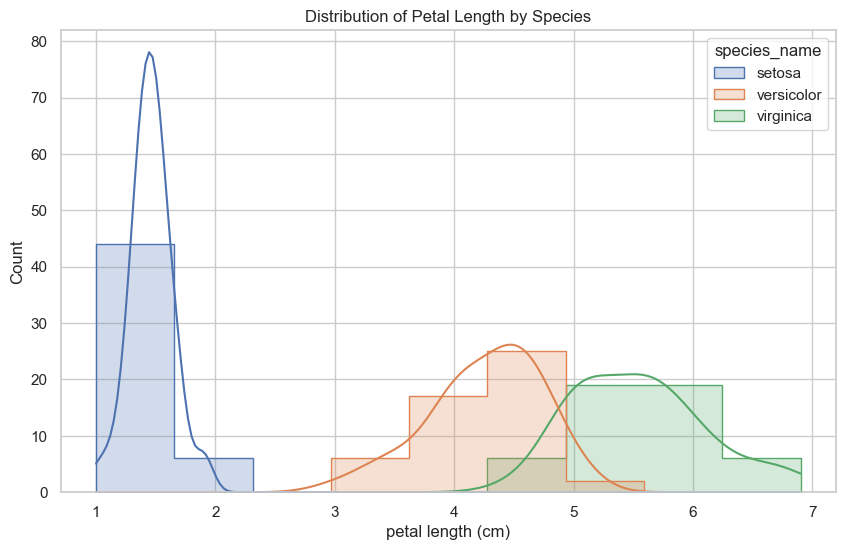

C:\Users\Bert\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Bert\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Bert\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Bert\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows wi

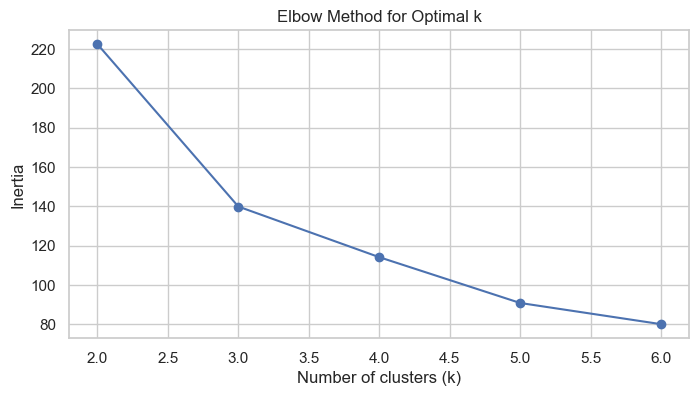

C:\Users\Bert\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


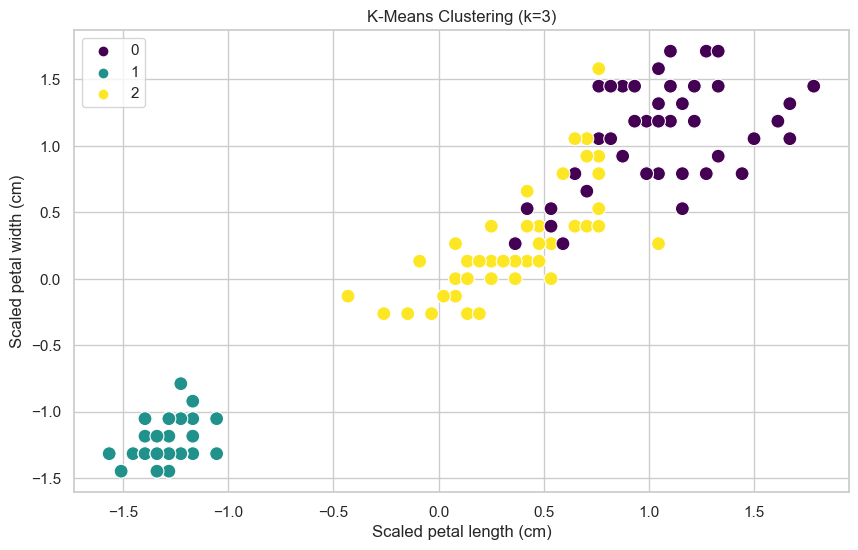


Adjusted Rand Index: 0.6201


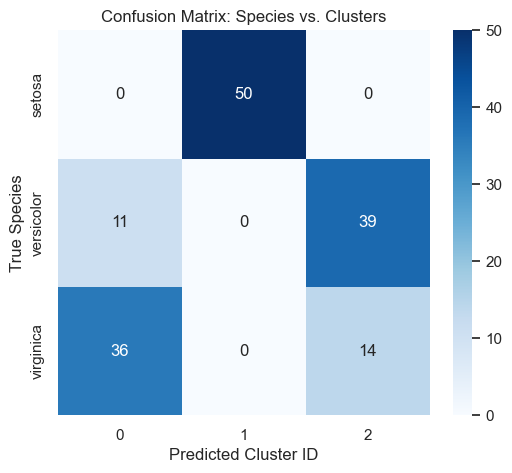

C:\Users\Bert\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


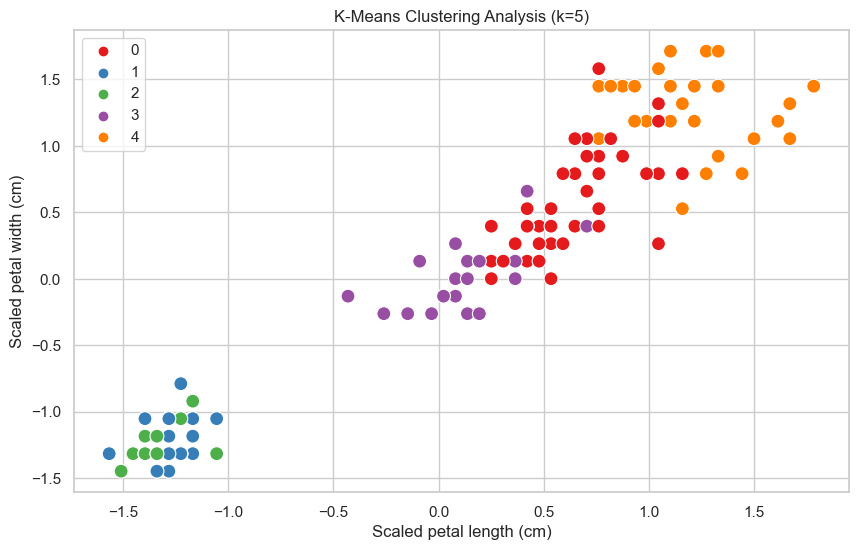

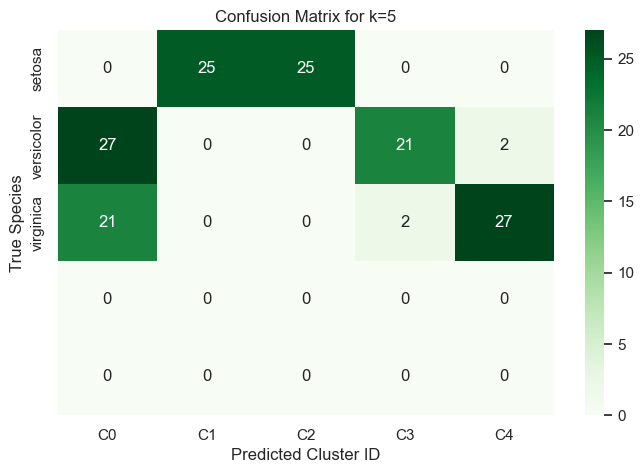

Adjusted Rand Index for k=5: 0.4181


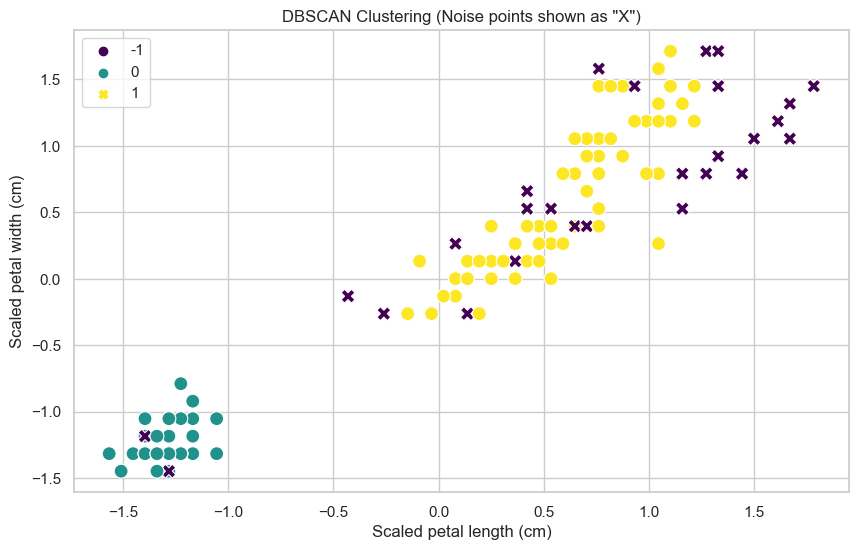

In [17]:

#setup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, adjusted_rand_score

#grabbing iris and preparing
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species_name'] = [iris.target_names[i] for i in iris.target]

print("First 5 rows:")
print(df.head())
print("\nSummary Statistics:")
print(df.describe())

#visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="petal length (cm)", hue="species_name", kde=True, element="step")
plt.title("Distribution of Petal Length by Species")
plt.show()

#processing
X = iris.data
y_true = iris.target
feature_names = iris.feature_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#elbow method to find optiml number of clusters
inertias = []
k_range = range(2, 7)
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

#K-means
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

#cluster visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 2], y=X_scaled[:, 3], hue=clusters, palette='viridis', s=100)
plt.xlabel(f'Scaled {feature_names[2]}')
plt.ylabel(f'Scaled {feature_names[3]}')
plt.title(f'K-Means Clustering (k={k_optimal})')
plt.show()

#rand
ari = adjusted_rand_score(y_true, clusters)
print(f"\nAdjusted Rand Index: {ari:.4f}")

cm = confusion_matrix(y_true, clusters)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[0, 1, 2], yticklabels=iris.target_names)
plt.xlabel('Predicted Cluster ID')
plt.ylabel('True Species')
plt.title('Confusion Matrix: Species vs. Clusters')
plt.show()

k_test = 5 
kmeans_test = KMeans(n_clusters=k_test, random_state=42, n_init=10)
clusters_test = kmeans_test.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 2], y=X_scaled[:, 3], hue=clusters_test, palette='Set1', s=100)
plt.xlabel(f'Scaled {feature_names[2]}')
plt.ylabel(f'Scaled {feature_names[3]}')
plt.title(f'K-Means Clustering Analysis (k={k_test})')
plt.show()

#confusion matrix
cm_test = confusion_matrix(y_true, clusters_test)
plt.figure(figsize=(8, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', 
            xticklabels=[f'C{i}' for i in range(k_test)], 
            yticklabels=iris.target_names)
plt.xlabel('Predicted Cluster ID')
plt.ylabel('True Species')
plt.title(f'Confusion Matrix for k={k_test}')
plt.show()

ari_test = adjusted_rand_score(y_true, clusters_test)
print(f"Adjusted Rand Index for k={k_test}: {ari_test:.4f}")


#additional setup for dbscan
import numpy as np
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_clusters = dbscan.fit_predict(X_scaled)

#visualizATION
plt.figure(figsize=(10, 6))

sns.scatterplot(x=X_scaled[:, 2], y=X_scaled[:, 3], hue=db_clusters, 
                palette='viridis', s=100, style=(db_clusters == -1))
plt.xlabel(f'Scaled {feature_names[2]}')
plt.ylabel(f'Scaled {feature_names[3]}')
plt.title('DBSCAN Clustering (Noise points shown as "X")')
plt.show()